### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats
import plotly.graph_objects as go 
# 1. Generazione del campione 
shape_param = 1.0
# "Congeliamo" la distribuzione con il parametro di forma (shape) pari a 1
gamma_dist = stats.gamma(shape_param)

# Generiamo 1000 valori casuali (Random Variates)
np.random.seed(42) # Per riproducibilità
campione = gamma_dist.rvs(size=1000)


# 2. Stima del parametro con il metodo fit()

# Il metodo fit restituisce: 
shape_stimato, loc_stimato, scale_stimato = stats.gamma.fit(campione)

print("--- STIMA DEI PARAMETRI ---")
print(f"Parametro di forma (shape) reale: {shape_param}")
print(f"Parametro di forma (shape) stimato dal fit: {shape_stimato:.4f}")
print("-" * 40)


# 3. Calcolo della Varianza

# Varianza teorica dalla distribuzione congelata
varianza_teorica = gamma_dist.var()
# Varianza campionaria calcolata dai dati generati
varianza_campionaria = np.var(campione)

print("--- ANALISI DELLA VARIANZA ---")
print(f"Varianza teorica: {varianza_teorica}")
print(f"Varianza campionaria: {varianza_campionaria:.4f}")
print("-" * 40)


# 4. Grafico Interattivo: Istogramma + PDF (Plotly)

# Creiamo un asse x continuo per calcolare la PDF teorica
x_pdf = np.linspace(0, np.max(campione), 500)
y_pdf = gamma_dist.pdf(x_pdf)

fig_pdf = go.Figure()

# Istogramma del campione (normalizzato per mostrare la densità)
fig_pdf.add_trace(go.Histogram(
    x=campione,
    histnorm='probability density',
    name='Campione (Istogramma)',
    marker_color='rgba(100, 149, 237, 0.6)',
    nbinsx=40
))

# Curva della PDF teorica
fig_pdf.add_trace(go.Scatter(
    x=x_pdf,
    y=y_pdf,
    mode='lines',
    name='PDF Teorica',
    line=dict(color='red', width=3)
))

fig_pdf.update_layout(
    title='Istogramma del Campione vs PDF della Distribuzione Gamma',
    xaxis_title='Valore',
    yaxis_title='Densità',
    template='plotly_white'
)
fig_pdf.write_html("grafico.html")


# 5. Grafico Extra: Funzione di Distribuzione Cumulativa (CDF)

y_cdf = gamma_dist.cdf(x_pdf)

fig_cdf = go.Figure()

fig_cdf.add_trace(go.Scatter(
    x=x_pdf,
    y=y_cdf,
    mode='lines',
    name='CDF Teorica',
    line=dict(color='green', width=3)
))

fig_cdf.update_layout(
    title='Funzione di Distribuzione Cumulativa (CDF) - Gamma(1)',
    xaxis_title='Valore',
    yaxis_title='Probabilità Cumulata P(X <= x)',
    template='plotly_white'
)
fig_cdf.write_html("grafico.html")

--- STIMA DEI PARAMETRI ---
Parametro di forma (shape) reale: 1.0
Parametro di forma (shape) stimato dal fit: 0.9596
----------------------------------------
--- ANALISI DELLA VARIANZA ---
Varianza teorica: 1.0
Varianza campionaria: 0.9448
----------------------------------------


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

In [2]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt



### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [1]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df




,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


=== RISULTATI CON SCIKIT-LEARN ===
Intercetta (β0): 29.5999
Pendenza/Coefficiente (β1): -0.0412
R² (Coefficiente di determinazione): 0.7183
Equazione: mpg = 29.60 + (-0.0412) * disp

=== REPORT STATISTICO COMPLETO ===
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     76.51
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           9.38e-10
Time:                        05:58:30   Log-Likelihood:                -82.105
No. Observations:                  32   AIC:                             168.2
Df Residuals:                      30   BIC:                             171.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                  

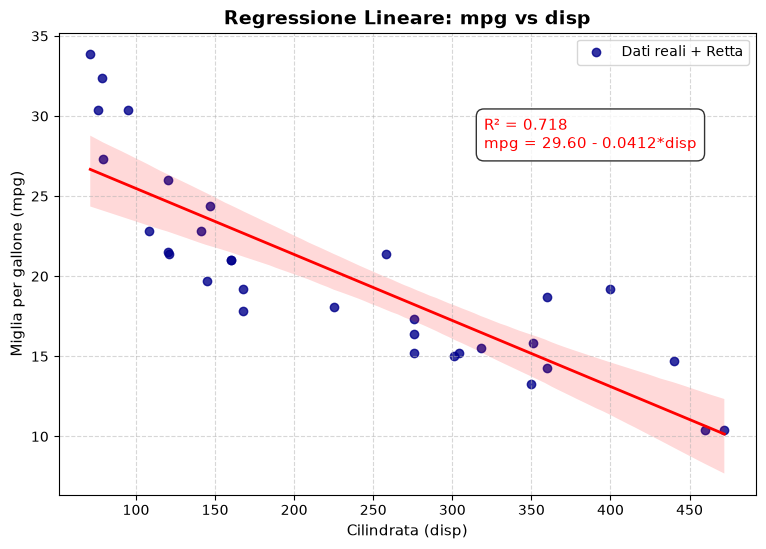

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# 1. Caricamento del dataset 
mtcars = sm.datasets.get_rdataset("mtcars", "datasets").data

# Definiamo la variabile indipendente X (disp) e dipendente y (mpg)
X = mtcars[['disp']]  
y = mtcars['mpg']


# APPROCCIO 1: Scikit-Learn (Stile Machine Learning)

modello_sk = LinearRegression()
modello_sk.fit(X, y)

intercetta = modello_sk.intercept_
pendenza = modello_sk.coef_[0]
r_quadrato = modello_sk.score(X, y)

print("=== RISULTATI CON SCIKIT-LEARN ===")
print(f"Intercetta (β0): {intercetta:.4f}")
print(f"Pendenza/Coefficiente (β1): {pendenza:.4f}")
print(f"R² (Coefficiente di determinazione): {r_quadrato:.4f}")
print(f"Equazione: mpg = {intercetta:.2f} + ({pendenza:.4f}) * disp\n")



# APPROCCIO 2: Statsmodels (Stile Statistico/Report completo)


X_stat = sm.add_constant(X)
modello_sm = sm.OLS(y, X_stat).fit()

print("=== REPORT STATISTICO COMPLETO ===")
print(modello_sm.summary())



# 3. GRAFICO DELLA RETTA DI REGRESSIONE

plt.figure(figsize=(9, 6))

# seaborn gestisce in automatico lo scatter plot e la linea di regressione con intervallo di confidenza
sns.regplot(data=mtcars, x='disp', y='mpg', color='darkblue', 
            line_kws={"color": "red", "linewidth": 2}, label="Dati reali + Retta")

# Aggiungiamo i dettagli al grafico
plt.title("Regressione Lineare: mpg vs disp", fontsize=14, fontweight='bold')
plt.xlabel("Cilindrata (disp)", fontsize=11)
plt.ylabel("Miglia per gallone (mpg)", fontsize=11)

# Inseriamo l'equazione e l'R² direttamente nel grafico
testo_grafico = f"R² = {r_quadrato:.3f}\nmpg = {intercetta:.2f} - {abs(pendenza):.4f}*disp"
plt.text(320, 28, testo_grafico, color='red', fontsize=11,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()